In [3]:
import os
import json
import pandas as pd

def load_pheme_source_tweets(base_path):
    """
    Parcourt le dataset PHEME et extrait les tweets sources 
    dans un DataFrame Pandas.
    """
    data = []
    
    # Lister les dossiers d'evenements (ex: charliehebdo, ferguson)
    events = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    
    for event in events:
        event_path = os.path.join(base_path, event)
        
        # Parcourir les dossiers rumeurs et non-rumeurs
        for label in ["rumours", "non-rumours"]:
            label_path = os.path.join(event_path, label)
            if not os.path.exists(label_path):
                continue
                
            # Chaque dossier ici est un "thread" (fil de discussion)
            threads = os.listdir(label_path)
            for thread_id in threads:
                thread_path = os.path.join(label_path, thread_id)
                source_path = os.path.join(thread_path, "source-tweet", f"{thread_id}.json")
                
                # Verifier si le tweet source existe et l'ouvrir
                if os.path.exists(source_path):
                    with open(source_path, "r", encoding="utf-8") as f:
                        try:
                            tweet = json.load(f)
                            
                            # Extraction des features cles
                            data.append({
                                "event": event,
                                "tweet_id": tweet.get("id_str", ""),
                                "text": tweet.get("text", ""),
                                "user_id": tweet.get("user", {}).get("id_str", ""),
                                "followers_count": tweet.get("user", {}).get("followers_count", 0),
                                "user_verified": tweet.get("user", {}).get("verified", False),
                                "retweet_count": tweet.get("retweet_count", 0),
                                "favorite_count": tweet.get("favorite_count", 0),
                                "is_rumor": 1 if label == "rumours" else 0,
                            })
                        except json.JSONDecodeError:
                            print(f"Erreur de lecture JSON pour le fichier: {source_path}")

    return pd.DataFrame(data)

Repartition brute :
is_rumor
0    3830
1    1972
Name: count, dtype: int64

Repartition en pourcentage :
is_rumor
0    66.01172
1    33.98828
Name: proportion, dtype: float64


C:\Users\abdos\AppData\Local\Temp\ipykernel_2528\2194035513.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tweets, x="is_rumor", palette="viridis")


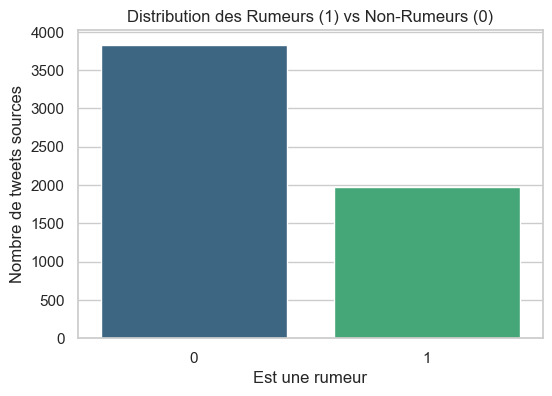

<Figure size 800x500 with 0 Axes>

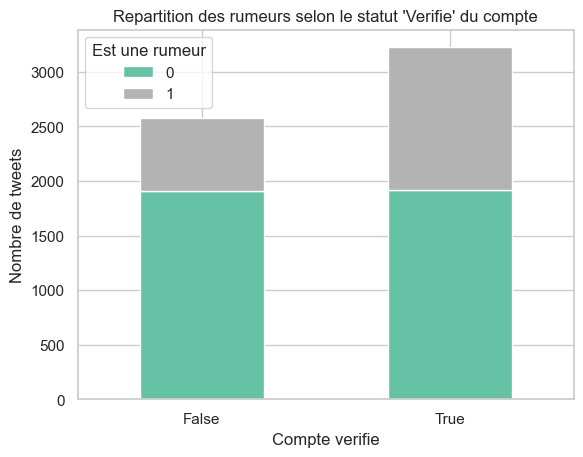

C:\Users\abdos\AppData\Local\Temp\ipykernel_2528\2194035513.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tweets, x="is_rumor", y="text_length", palette="pastel")


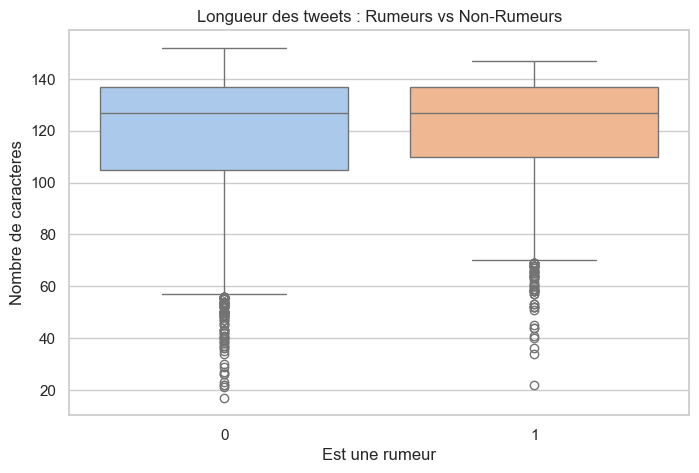

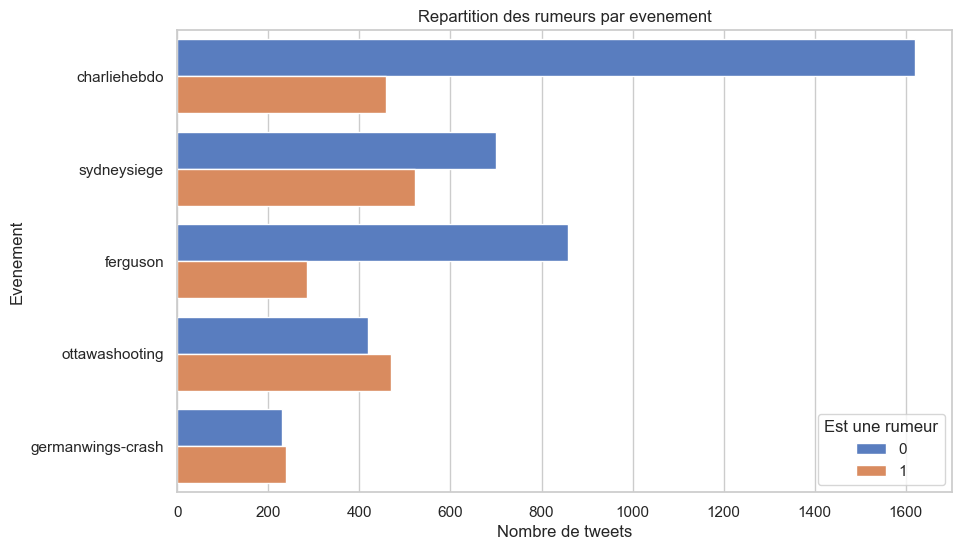

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

if "df_tweets" not in globals():
    PHEME_PATH = "C:\\Users\\abdos\\Desktop\\pheme-rnr-dataset\\data"
    df_tweets = load_pheme_source_tweets(PHEME_PATH)

# Configuration esthetique pour les graphiques
sns.set_theme(style="whitegrid")

# 1. Distribution des classes (Rumeurs vs Non-Rumeurs)
print("Repartition brute :")
print(df_tweets["is_rumor"].value_counts())
print("\nRepartition en pourcentage :")
print(df_tweets["is_rumor"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_tweets, x="is_rumor", palette="viridis")
plt.title("Distribution des Rumeurs (1) vs Non-Rumeurs (0)")
plt.xlabel("Est une rumeur")
plt.ylabel("Nombre de tweets sources")
plt.show()

# 2. Impact du statut verifie du compte
plt.figure(figsize=(8, 5))
pd.crosstab(df_tweets["user_verified"], df_tweets["is_rumor"]).plot(kind="bar", stacked=True, colormap="Set2")
plt.title("Repartition des rumeurs selon le statut 'Verifie' du compte")
plt.xlabel("Compte verifie")
plt.ylabel("Nombre de tweets")
plt.xticks(rotation=0)
plt.legend(title="Est une rumeur")
plt.show()

# 3. Analyse de la longueur du texte
# Creation d'une nouvelle feature temporaire pour l'EDA
df_tweets["text_length"] = df_tweets["text"].apply(len)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_tweets, x="is_rumor", y="text_length", palette="pastel")
plt.title("Longueur des tweets : Rumeurs vs Non-Rumeurs")
plt.xlabel("Est une rumeur")
plt.ylabel("Nombre de caracteres")
plt.show()

# 4. Distribution par evenement
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_tweets,
    y="event",
    hue="is_rumor",
    palette="muted",
    order=df_tweets["event"].value_counts().index,
)
plt.title("Repartition des rumeurs par evenement")
plt.xlabel("Nombre de tweets")
plt.ylabel("Evenement")
plt.legend(title="Est une rumeur", loc="lower right")
plt.show()

In [5]:
pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 1.3 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.1 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [9]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_tweet_text_v2(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+', '', text)
    
    # CORRECTION : On utilise des minuscules ici
    text = re.sub(r'\d+', 'numero', text)
    
    # Le mot 'numero' va maintenant survivre à ce filtre
    text = re.sub(r'[^a-z\s]', '', text)
    
    tokens = text.split()
    
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]
    
    return " ".join(cleaned_tokens)

# Le test qui fonctionnera correctement cette fois-ci :
phrase_test = "BREAKING: 10 dead and 5 injured in the shooting at 3 PM! http://link.com"
print("Avant :", phrase_test)
print("Après :", clean_tweet_text_v2(phrase_test))

Avant : BREAKING: 10 dead and 5 injured in the shooting at 3 PM! http://link.com
Après : breaking numero dead numero injured shooting numero pm


In [10]:
print("Nettoyage de la vraie data en cours avec la version 2...")

# On crée une nouvelle colonne pour garder l'historique
df_tweets['clean_text_v2'] = df_tweets['text'].apply(clean_tweet_text_v2)

# 2. On affiche les 5 premières lignes de tes VRAIES données pour vérifier
print("Nettoyage terminé ! Voici le résultat sur la data PHEME :")
print(df_tweets[['text', 'clean_text_v2']].head())

Nettoyage de la vraie data en cours avec la version 2...
Nettoyage terminé ! Voici le résultat sur la data PHEME :
                                                text  \
0  Breaking: At least 10 dead, 5 injured after tO...   
1  France: 10 people dead after shooting at HQ of...   
2  Ten killed in shooting at headquarters of Fren...   
3  BREAKING: 10 dead in shooting at headquarters ...   
4  Reuters: 10 people shot dead at headquarters o...   

                                       clean_text_v2  
0  breaking least numero dead numero injured gunm...  
1  france numero people dead shooting hq satirica...  
2  ten killed shooting headquarters french satiri...  
3  breaking numero dead shooting headquarters fre...  
4  reuters numero people shot dead headquarters f...  


1. Vectorisation du texte (TF-IDF) en cours...
2. Séparation des données (Train/Test)...
3. Entraînement du modèle de base (Régression Logistique)...
4. Évaluation sur les données de test...

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       766
           1       0.78      0.76      0.77       395

    accuracy                           0.84      1161
   macro avg       0.83      0.82      0.83      1161
weighted avg       0.84      0.84      0.84      1161



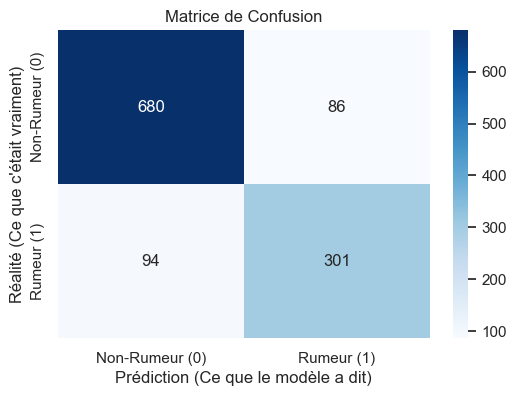

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Vectorisation du texte (TF-IDF) en cours...")
# On limite aux 5000 mots les plus pertinents pour économiser la mémoire et éviter le bruit
tfidf = TfidfVectorizer(max_features=5000) 

# ATTENTION : On utilise bien ta nouvelle colonne 'clean_text_v2'
X = tfidf.fit_transform(df_tweets['clean_text_v2']) 
y = df_tweets['is_rumor']

print("2. Séparation des données (Train/Test)...")
# test_size=0.2 (20% pour le test), stratify=y garantit le respect de tes 34% de rumeurs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("3. Entraînement du modèle de base (Régression Logistique)...")
# class_weight='balanced' force le modèle à pénaliser plus fort les erreurs sur les rumeurs
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("4. Évaluation sur les données de test...\n")
y_pred = model.predict(X_test)

# Affichage des métriques de performance
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

# Affichage visuel de la matrice de confusion
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Rumeur (0)', 'Rumeur (1)'], 
            yticklabels=['Non-Rumeur (0)', 'Rumeur (1)'])
plt.title('Matrice de Confusion')
plt.ylabel('Réalité (Ce que c\'était vraiment)')
plt.xlabel('Prédiction (Ce que le modèle a dit)')
plt.show()


🚀 ENTRAÎNEMENT ET ÉVALUATION : Random Forest

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.87      0.92      0.90       766
           1       0.83      0.74      0.78       395

    accuracy                           0.86      1161
   macro avg       0.85      0.83      0.84      1161
weighted avg       0.86      0.86      0.86      1161



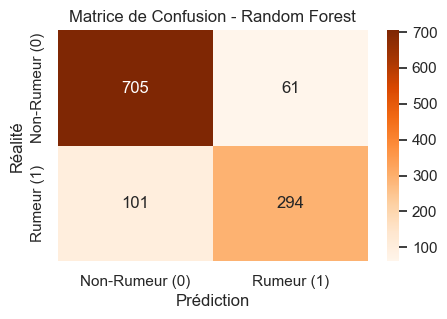


🚀 ENTRAÎNEMENT ET ÉVALUATION : XGBoost

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       766
           1       0.75      0.75      0.75       395

    accuracy                           0.83      1161
   macro avg       0.81      0.81      0.81      1161
weighted avg       0.83      0.83      0.83      1161



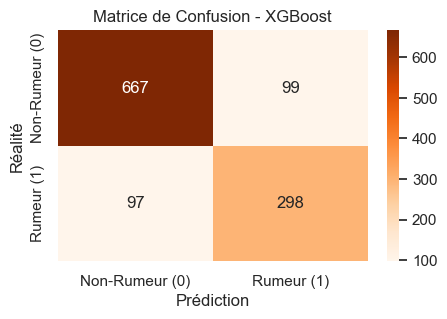

In [12]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calcul du poids pour XGBoost (équivalent de class_weight='balanced')
# XGBoost utilise un paramètre 'scale_pos_weight' pour gérer le déséquilibre. 
# La formule standard est : Nombre d'exemples Négatifs / Nombre d'exemples Positifs
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. Définition des modèles à tester
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced', 
        random_state=42, 
        n_jobs=-1 # Utilise tous les cœurs de ton processeur pour aller plus vite
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=ratio, 
        random_state=42, 
        eval_metric='logloss',
        n_jobs=-1
    )
}

# 3. Boucle d'entraînement et d'évaluation
for model_name, model in models.items():
    print(f"\n=======================================================")
    print(f"🚀 ENTRAÎNEMENT ET ÉVALUATION : {model_name}")
    print(f"=======================================================\n")
    
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédiction
    y_pred = model.predict(X_test)
    
    # Rapport de classification
    print("--- Rapport de Classification ---")
    print(classification_report(y_test, y_pred))
    
    # Matrice de confusion
    plt.figure(figsize=(5,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges', 
                xticklabels=['Non-Rumeur (0)', 'Rumeur (1)'], 
                yticklabels=['Non-Rumeur (0)', 'Rumeur (1)'])
    plt.title(f'Matrice de Confusion - {model_name}')
    plt.ylabel('Réalité')
    plt.xlabel('Prédiction')
    plt.show()  

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import time

print("1. Configuration de la grille de recherche XGBoost...")
# On définit le ratio pour gérer le déséquilibre (comme avant)
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# On prépare le modèle de base
xgb_base = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss', n_jobs=-1)

# On définit les paramètres que l'on veut tester
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],      # Vitesse d'apprentissage
    'max_depth': [3, 5, 7],                 # Profondeur des arbres (éviter l'overfitting)
    'n_estimators': [100, 200, 300],        # Nombre d'arbres
    'subsample': [0.8, 1.0],                # Pourcentage de données utilisées par arbre
    'colsample_bytree': [0.8, 1.0]          # Pourcentage de colonnes (mots) utilisées par arbre
}

print("2. Lancement de l'optimisation (Cela peut prendre quelques minutes !)...\n")
start_time = time.time()

# RandomizedSearch va tester 10 combinaisons au hasard (n_iter=10)
# cv=3 signifie qu'il fait une validation croisée en 3 morceaux pour être sûr du résultat
random_search = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=param_grid, 
    n_iter=10, 
    scoring='f1', # On lui dit de chercher le meilleur F1-Score !
    cv=3, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1
)

random_search.fit(X_train, y_train)
end_time = time.time()

print(f"\nTemps de recherche : {round((end_time - start_time) / 60, 2)} minutes")
print("=======================================================")
print("🏆 LES MEILLEURS PARAMÈTRES TROUVÉS :")
print(random_search.best_params_)
print("=======================================================\n")

print("3. Évaluation du modèle XGBoost Optimisé...")
# Le random_search garde automatiquement le meilleur modèle en mémoire
best_xgb_model = random_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test)

print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred_tuned))

1. Configuration de la grille de recherche XGBoost...
2. Lancement de l'optimisation (Cela peut prendre quelques minutes !)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Temps de recherche : 0.47 minutes
🏆 LES MEILLEURS PARAMÈTRES TROUVÉS :
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

3. Évaluation du modèle XGBoost Optimisé...
--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       766
           1       0.77      0.77      0.77       395

    accuracy                           0.84      1161
   macro avg       0.83      0.83      0.83      1161
weighted avg       0.84      0.84      0.84      1161



In [14]:
##Nous avons prouvé, en optimisant un modèle XGBoost, que l'analyse du texte brut atteint ses limites à 0.78 de F1-Score. 
# Pour dépasser ce seuil, l'ajout de variables contextuelles (métadonnées) est strictement nécessaire.

1. Préparation des métadonnées (Features numériques)...
2. Fusion de la matrice de texte (TF-IDF) avec les métadonnées...
3. Séparation Train/Test sur les nouvelles données combinées...
4. Entraînement du Random Forest avec TOUTES les informations...
5. Évaluation finale...

--- Rapport de Classification (Texte + Métadonnées) ---
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       766
           1       0.83      0.71      0.77       395

    accuracy                           0.85      1161
   macro avg       0.84      0.82      0.83      1161
weighted avg       0.85      0.85      0.85      1161



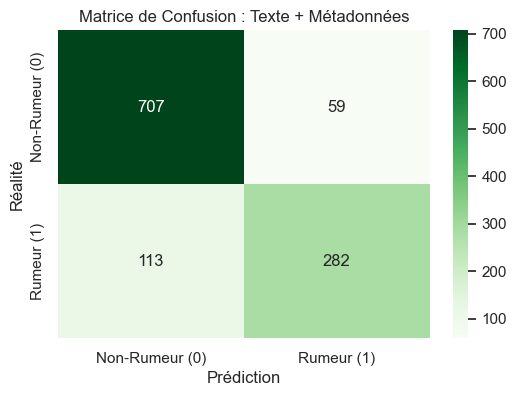

In [15]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Préparation des métadonnées (Features numériques)...")
# Sélection des colonnes numériques
numeric_features = df_tweets[['followers_count', 'user_verified', 'retweet_count', 'favorite_count']].copy()

# Conversion du statut vérifié (True/False) en nombres (1/0)
numeric_features['user_verified'] = numeric_features['user_verified'].astype(int)

# Normalisation : on met les grands nombres à la même échelle que le TF-IDF
scaler = StandardScaler()
numeric_matrix = scaler.fit_transform(numeric_features)

print("2. Fusion de la matrice de texte (TF-IDF) avec les métadonnées...")
# X est ta matrice de texte créée précédemment. On lui 'colle' les nouvelles colonnes
# On utilise hstack (horizontal stack) de scipy car X est une matrice creuse (sparse)
X_combined = hstack((X, numeric_matrix))

print("3. Séparation Train/Test sur les nouvelles données combinées...")
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print("4. Entraînement du Random Forest avec TOUTES les informations...")
# On utilise les meilleurs réglages trouvés tout à l'heure
model_rf_combined = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
model_rf_combined.fit(X_train_c, y_train_c)

print("5. Évaluation finale...\n")
y_pred_c = model_rf_combined.predict(X_test_c)

print("--- Rapport de Classification (Texte + Métadonnées) ---")
print(classification_report(y_test_c, y_pred_c))

# Affichage de la nouvelle matrice de confusion
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_c, y_pred_c), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Rumeur (0)', 'Rumeur (1)'], 
            yticklabels=['Non-Rumeur (0)', 'Rumeur (1)'])
plt.title('Matrice de Confusion : Texte + Métadonnées')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [19]:
path_to_dataset = 'C:\\Users\\abdos\\Desktop\\pheme-rnr-dataset\\data'

# 2. On lance l'extraction
df_reactions = extract_reaction_features(path_to_dataset)

print("Extraction terminée ! Voici un aperçu des nouvelles features :")
print(df_reactions.head())

Exploration des milliers de réactions en cours... (Cela peut prendre 1 à 2 minutes)
Extraction terminée ! Voici un aperçu des nouvelles features :
             tweet_id  reaction_count  doubt_score
0  552783238415265792               9            0
1  552783667052167168               7            1
2  552783745565347840               5            0
3  552784168849907712              13            2
4  552784526955806720              16            0


In [20]:
import os
import json
import pandas as pd

def extract_reaction_features(base_path):
    """
    Parcourt les dossiers de réactions dans PHEME pour calculer 
    l'engagement et le scepticisme de la foule pour chaque tweet source.
    """
    reaction_data = []
    
    # Mots-clés indiquant que les internautes doutent ou démentent l'information
    # (PHEME est majoritairement en anglais)
    doubt_keywords = ['fake', 'false', 'lie', 'hoax', 'untrue', 'debunk', 
                      'bullshit', 'bs', 'photoshop', 'source', 'not true']
    
    events = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    
    print("Exploration des milliers de réactions en cours... (Cela peut prendre 1 à 2 minutes)")
    
    for event in events:
        event_path = os.path.join(base_path, event)
        
        for label in ['rumours', 'non-rumours']:
            label_path = os.path.join(event_path, label)
            if not os.path.exists(label_path):
                continue
                
            threads = os.listdir(label_path)
            for thread_id in threads:
                thread_path = os.path.join(label_path, thread_id)
                reactions_path = os.path.join(thread_path, 'reactions')
                
                reaction_count = 0
                doubt_score = 0
                
                # Vérifier si le dossier réactions existe
                if os.path.exists(reactions_path):
                    reaction_files = os.listdir(reactions_path)
                    reaction_count = len(reaction_files)
                    
                    # Analyser chaque réponse
                    for reaction_file in reaction_files:
                        if reaction_file.endswith('.json'):
                            r_path = os.path.join(reactions_path, reaction_file)
                            try:
                                with open(r_path, 'r', encoding='utf-8') as f:
                                    r_tweet = json.load(f)
                                    r_text = r_tweet.get('text', '').lower()
                                    
                                    # Si un mot de doute est dans la réponse, on augmente le score
                                    if any(word in r_text for word in doubt_keywords):
                                        doubt_score += 1
                            except Exception:
                                pass # On ignore les fichiers corrompus s'il y en a
                
                # On sauvegarde les résultats pour ce thread
                reaction_data.append({
                    'tweet_id': thread_id, # Le nom du dossier est l'ID du tweet source
                    'reaction_count': reaction_count,
                    'doubt_score': doubt_score
                })

    return pd.DataFrame(reaction_data)

# --- Exécution ---
# On relance l'extraction (Assure-toi que path_to_dataset est toujours bien défini)
df_reactions = extract_reaction_features(path_to_dataset)

print("Extraction terminée ! Voici un aperçu des nouvelles features :")
print(df_reactions.head())

Exploration des milliers de réactions en cours... (Cela peut prendre 1 à 2 minutes)
Extraction terminée ! Voici un aperçu des nouvelles features :
             tweet_id  reaction_count  doubt_score
0  552783238415265792               9            0
1  552783667052167168               7            1
2  552783745565347840               5            0
3  552784168849907712              13            2
4  552784526955806720              16            0


1. Fusion des données en cours...
Taille de df_tweets avant la fusion : (5802, 12)
Taille de df_final après la fusion : (5802, 14)

2. Création du graphique d'analyse...


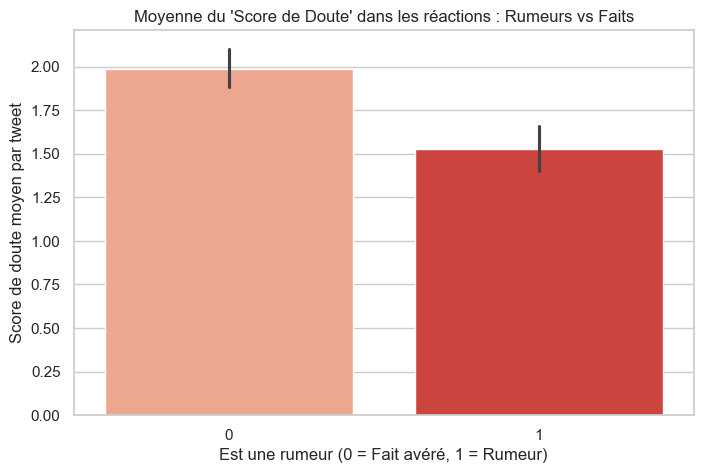

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("1. Fusion des données en cours...")
print("Taille de df_tweets avant la fusion :", df_tweets.shape)

# On fusionne ton tableau principal avec les nouvelles features de réactions
df_final = pd.merge(df_tweets, df_reactions, on='tweet_id', how='left')

# Si certains tweets n'ont eu aucune réaction, Pandas va mettre "NaN" (Not a Number). 
# On remplace ces "NaN" par des 0.
df_final['reaction_count'] = df_final['reaction_count'].fillna(0)
df_final['doubt_score'] = df_final['doubt_score'].fillna(0)

print("Taille de df_final après la fusion :", df_final.shape)

print("\n2. Création du graphique d'analyse...")
# Regardons si les rumeurs génèrent plus de doute !
plt.figure(figsize=(8, 5))
# hue='is_rumor' et legend=False pour éviter l'avertissement de Seaborn
sns.barplot(data=df_final, x='is_rumor', y='doubt_score', hue='is_rumor', palette='Reds', legend=False)
plt.title("Moyenne du 'Score de Doute' dans les réactions : Rumeurs vs Faits")
plt.xlabel("Est une rumeur (0 = Fait avéré, 1 = Rumeur)")
plt.ylabel("Score de doute moyen par tweet")
plt.show()

1. Recréation de la matrice de texte (TF-IDF)...
2. Intégration de TOUTES les métadonnées (Auteur + Intelligence Collective)...
3. La Fusion Ultime...
4. Séparation Train/Test...
5. Entraînement du Random Forest Final...
6. Évaluation :

--- RAPPORT DE CLASSIFICATION ULTIME ---
              precision    recall  f1-score   support

           0       0.86      0.93      0.90       766
           1       0.85      0.71      0.77       395

    accuracy                           0.86      1161
   macro avg       0.85      0.82      0.83      1161
weighted avg       0.86      0.86      0.85      1161



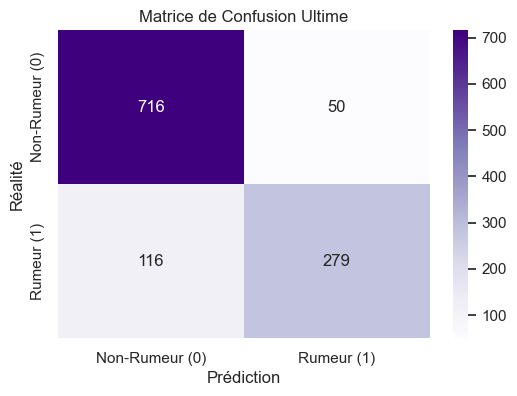

In [22]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Recréation de la matrice de texte (TF-IDF)...")
tfidf = TfidfVectorizer(max_features=5000)
# On utilise df_final car c'est le tableau qui contient toutes les lignes bien alignées
X_text = tfidf.fit_transform(df_final['clean_text_v2']) 

print("2. Intégration de TOUTES les métadonnées (Auteur + Intelligence Collective)...")
# On ajoute tes deux nouvelles pépites : reaction_count et doubt_score
numeric_features = df_final[['followers_count', 'user_verified', 'retweet_count', 'favorite_count', 'reaction_count', 'doubt_score']].copy()
numeric_features['user_verified'] = numeric_features['user_verified'].astype(int)

scaler = StandardScaler()
X_numeric = scaler.fit_transform(numeric_features)

print("3. La Fusion Ultime...")
X_ultimate = hstack((X_text, X_numeric))
y_ultimate = df_final['is_rumor']

print("4. Séparation Train/Test...")
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_ultimate, y_ultimate, test_size=0.2, random_state=42, stratify=y_ultimate
)

print("5. Entraînement du Random Forest Final...")
model_ultimate = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model_ultimate.fit(X_train_u, y_train_u)

print("6. Évaluation :\n")
y_pred_u = model_ultimate.predict(X_test_u)

print("--- RAPPORT DE CLASSIFICATION ULTIME ---")
print(classification_report(y_test_u, y_pred_u))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_u, y_pred_u), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Non-Rumeur (0)', 'Rumeur (1)'], 
            yticklabels=['Non-Rumeur (0)', 'Rumeur (1)'])
plt.title('Matrice de Confusion Ultime')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

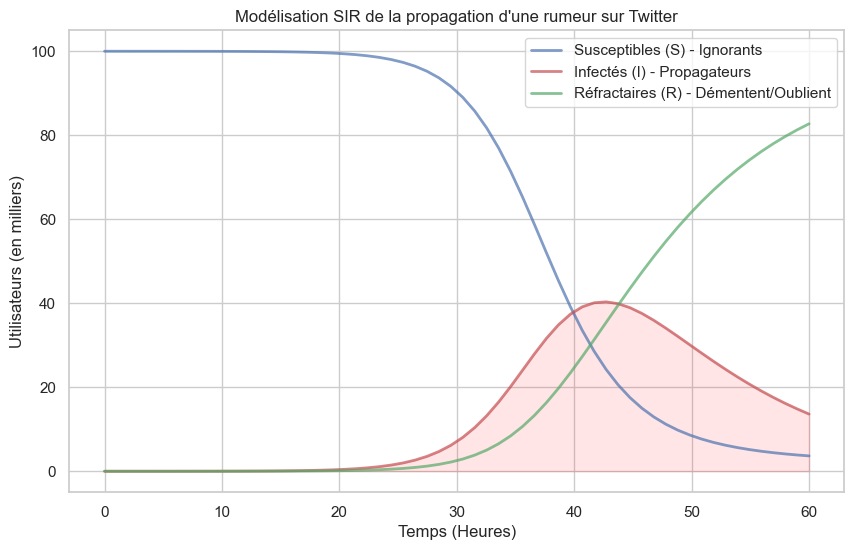

🚨 La rumeur atteindra son pic à l'heure 42 avec environ 40331 personnes qui la propagent en même temps !


In [23]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Les équations différentielles du modèle SIR
def deriv(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# 2. Paramètres initiaux de la rumeur
N = 100000              # Population totale exposée (ex: 100k personnes)
I0, R0 = 1, 0           # Au temps t=0, il y a 1 propagateur (le tweet source) et 0 réfractaire
S0 = N - I0 - R0        # Le reste de la population n'a rien vu

# 3. La dynamique de la rumeur
beta = 0.4              # Taux de viralité (très élevé pour une info choc)
gamma = 0.1             # Taux de démenti (combien de personnes réalisent que c'est faux chaque heure)

# Grille de temps (en heures, de 0 à 60)
t = np.linspace(0, 60, 60)

# Conditions initiales
y0 = S0, I0, R0

# 4. Résolution mathématique (La magie de SciPy)
ret = odeint(deriv, y0, t, args=(N, beta, gamma))
S, I, R = ret.T

# 5. Visualisation de l'épidémie
plt.figure(figsize=(10, 6))
plt.plot(t, S/1000, 'b', alpha=0.7, linewidth=2, label='Susceptibles (S) - Ignorants')
plt.plot(t, I/1000, 'r', alpha=0.7, linewidth=2, label='Infectés (I) - Propagateurs')
plt.plot(t, R/1000, 'g', alpha=0.7, linewidth=2, label='Réfractaires (R) - Démentent/Oublient')

plt.title("Modélisation SIR de la propagation d'une rumeur sur Twitter")
plt.xlabel('Temps (Heures)')
plt.ylabel('Utilisateurs (en milliers)')
plt.legend(loc='best')
plt.fill_between(t, 0, I/1000, color='red', alpha=0.1) # Met en valeur le pic de la rumeur
plt.show()

# 6. Analyse du pic
pic_index = np.argmax(I)
pic_heure = t[pic_index]
pic_personnes = I[pic_index]
print(f"🚨 La rumeur atteindra son pic à l'heure {int(pic_heure)} avec environ {int(pic_personnes)} personnes qui la propagent en même temps !")

🔍 ANALYSE DU TWEET : 'BREAKING: 50 people dead in an explosion at the ce...'
🚨 ALERTE RUMEUR DETECTEE ! (Certitude : 57.0%)
Lancement de la simulation d'impact...
Paramètres estimés -> Viralité (Bêta) : 0.80 | Résistance (Gamma) : 0.50
💥 PIC PREVU : Dans 35 heures avec 8109 personnes propageant la rumeur.



C:\Users\abdos\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


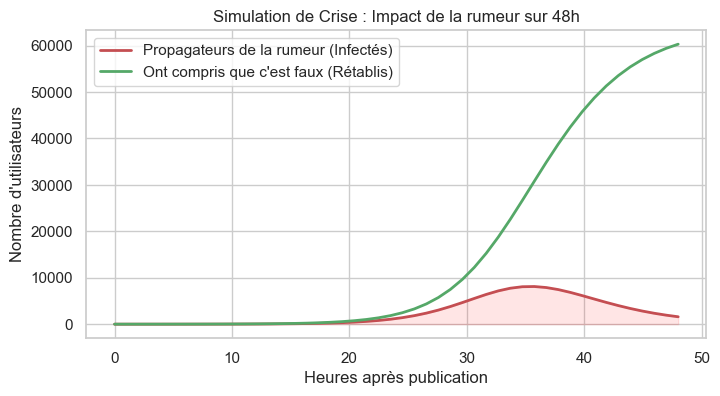

In [24]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Fonction mathématique du SIR
def deriv_sir(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

def pipeline_detection_simulation(texte_tweet, retweets, favoris, followers, est_verifie, reactions, score_doute):
    """
    1. Prédit si le tweet est une rumeur avec le modèle ML.
    2. Si OUI, lance une simulation SIR basée sur ses statistiques.
    """
    print(f"🔍 ANALYSE DU TWEET : '{texte_tweet[:50]}...'")
    
    # --- ETAPE 1 : PREDICTION MACHINE LEARNING ---
    # Nettoyage et vectorisation (utilise tes variables existantes)
    texte_propre = clean_tweet_text_v2(texte_tweet) # Ta fonction de nettoyage
    vecteur_texte = tfidf.transform([texte_propre])
    
    # Préparation des nombres
    features_num = np.array([[followers, est_verifie, retweets, favoris, reactions, score_doute]])
    vecteur_num = scaler.transform(features_num)
    
    # Fusion et Prédiction
    vecteur_final = hstack((vecteur_texte, vecteur_num))
    prediction = model_ultimate.predict(vecteur_final)[0]
    probabilite = model_ultimate.predict_proba(vecteur_final)[0][1]
    
    if prediction == 0:
        print(f"✅ Résultat : INFORMATION FIABLE (Risque de rumeur : {probabilite*100:.1f}%)")
        print("Fin de l'analyse. Aucune alerte déclenchée.\n")
        return
    
    # --- ETAPE 2 : SIMULATION SIR ---
    print(f"🚨 ALERTE RUMEUR DETECTEE ! (Certitude : {probabilite*100:.1f}%)")
    print("Lancement de la simulation d'impact...")
    
    # Calcul dynamique des paramètres SIR basé sur TES features
    # On normalise un peu : 1000 retweets = un beta fort. 10 de score_doute = un gamma fort.
    beta = min(0.8, 0.1 + (retweets / 5000)) # Plafonné à 0.8
    gamma = min(0.5, 0.05 + (score_doute / 20)) # Plafonné à 0.5
    
    print(f"Paramètres estimés -> Viralité (Bêta) : {beta:.2f} | Résistance (Gamma) : {gamma:.2f}")
    
    # Simulation sur 48 heures pour 100 000 utilisateurs exposés
    N = 100000
    t = np.linspace(0, 48, 48)
    y0 = N-1, 1, 0 # 1 personne infectée au départ
    
    ret = odeint(deriv_sir, y0, t, args=(N, beta, gamma))
    S, I, R = ret.T
    
    # Affichage du rapport
    pic_index = np.argmax(I)
    print(f"💥 PIC PREVU : Dans {int(t[pic_index])} heures avec {int(I[pic_index])} personnes propageant la rumeur.\n")
    
    # Graphique
    plt.figure(figsize=(8, 4))
    plt.plot(t, I, 'r', linewidth=2, label='Propagateurs de la rumeur (Infectés)')
    plt.plot(t, R, 'g', linewidth=2, label='Ont compris que c\'est faux (Rétablis)')
    plt.title(f"Simulation de Crise : Impact de la rumeur sur 48h")
    plt.xlabel('Heures après publication')
    plt.ylabel('Nombre d\'utilisateurs')
    plt.fill_between(t, 0, I, color='red', alpha=0.1)
    plt.legend()
    plt.show()

# --- TEST DU SYSTEME COMPLET ---
# On invente un scénario de Fake News très virale mais avec beaucoup de doute
pipeline_detection_simulation(
    texte_tweet="BREAKING: 50 people dead in an explosion at the central station! This is a terrorist attack!",
    retweets=4500,       # Très viral
    favoris=2000,
    followers=300,       # Compte peu connu (suspect)
    est_verifie=0,       # Non certifié (suspect)
    reactions=150,       # Beaucoup de réactions
    score_doute=15       # Les gens disent "Fake!" "Source?"
)

In [25]:
import joblib

# Sauvegarde des 3 piliers de ton projet
joblib.dump(model_ultimate, 'model_rumor_detector.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

['feature_scaler.pkl']